Device: cpu
Classes: ['bridging', 'clean', 'glitch', 'stuck_at']
Gate vocab: ['and', 'nand', 'nor', 'not', 'or', 'other', 'xor']
Train nets: 24 | Test nets: 6
Built 24 train + 6 test joint graphs.
Final input dim: 35
Train graphs: 24 | Test graphs: 6
Class weights: [1.3747077  0.00848948 1.3747077  1.2420951 ]
[Epoch 01] train_loss=0.7420 train_acc=0.4608 val_loss=2.1385 val_acc=0.1770
[Epoch 05] train_loss=0.2012 train_acc=0.5277 val_loss=1.8254 val_acc=0.0765
[Epoch 10] train_loss=0.1387 train_acc=0.5454 val_loss=1.7280 val_acc=0.1565
[Epoch 15] train_loss=0.1206 train_acc=0.5840 val_loss=1.9240 val_acc=0.1332
[Epoch 20] train_loss=0.1122 train_acc=0.6172 val_loss=1.7263 val_acc=0.2230
[Epoch 25] train_loss=0.1068 train_acc=0.6432 val_loss=1.6670 val_acc=0.1860
[Epoch 30] train_loss=0.1006 train_acc=0.6862 val_loss=2.5512 val_acc=0.2115
[Epoch 35] train_loss=0.0980 train_acc=0.7145 val_loss=2.5196 val_acc=0.4620
[Epoch 40] train_loss=0.0946 train_acc=0.7504 val_loss=2.6730 val_acc=0.

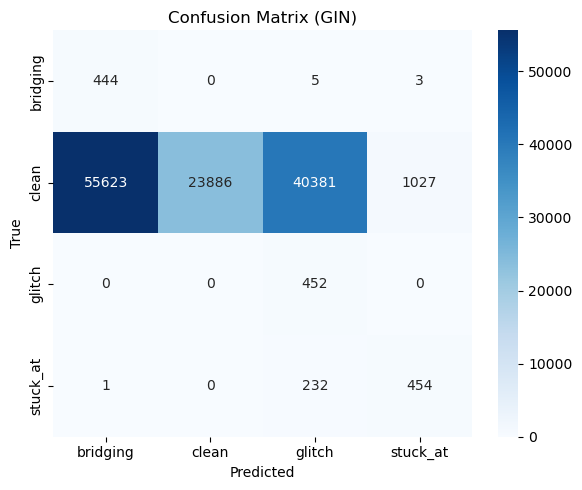

In [4]:
# train_eval_GIN.py
# End-to-end GIN node-level classifier with relational features
import math
from collections import defaultdict, deque
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINConv
from torch_geometric.utils import add_self_loops
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------
# Config
# -------------------
NODES_FILE = "nodes_enhanced.csv"
EDGES_FILE = "edges_enhanced.csv"

EPOCHS = 40
LR = 7e-4
BATCH_SIZE = 1
HID = 128
N_LAYERS = 3
DROPOUT = 0.5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PRINT_EVERY = 5
rng = np.random.default_rng(42)

print("Device:", DEVICE)

# -------------------
# Load CSVs & basic checks
# -------------------
nodes_df = pd.read_csv(NODES_FILE)
edges_df = pd.read_csv(EDGES_FILE)

required_node_cols = [
    "netlist_file","fault_type","node_id","gate_type","label",
    "total_degree","path_depth","CC0_exact","CC1_exact","CO_exact",
    "dist_to_PO","fanout","fanout_norm","gate_delay"
]
for c in required_node_cols:
    if c not in nodes_df.columns:
        raise SystemExit(f"Missing column in nodes CSV: {c}")

if "fan_out" not in edges_df.columns:
    # allow 'fanout' or create zero column
    if "fanout" in edges_df.columns:
        edges_df = edges_df.rename(columns={"fanout":"fan_out"})
    else:
        edges_df["fan_out"] = 0.0

# -------------------
# Labels & gate vocab
# -------------------
le = LabelEncoder()
nodes_df["cls"] = le.fit_transform(nodes_df["fault_type"])
class_names = list(le.classes_)
num_classes = len(class_names)
print("Classes:", class_names)

gate_norm = nodes_df["gate_type"].astype(str).str.lower()
logic_whitelist = {"and","nand","nor","not","or","xor","buf","pi","po","other"}
gate_norm = gate_norm.where(gate_norm.isin(logic_whitelist), other="other")
gate_vocab = sorted(gate_norm.unique().tolist())
g2i = {g:i for i,g in enumerate(gate_vocab)}
G = len(gate_vocab)
print("Gate vocab:", gate_vocab)

base_num_cols = [
    "total_degree","path_depth","CC0_exact","CC1_exact","CO_exact",
    "dist_to_PO","fanout_norm","gate_delay"
]

# -------------------
# Train/test split by netlist
# -------------------
netlists = nodes_df["netlist_file"].drop_duplicates().values
train_nets, test_nets = train_test_split(netlists, test_size=0.2, random_state=42, shuffle=True)
print(f"Train nets: {len(train_nets)} | Test nets: {len(test_nets)}")

# -------------------
# Helper: build joint graphs for list of nets
# -------------------
def build_joint_graphs(nets):
    graphs = []
    for nf in nets:
        nd_sub = nodes_df[nodes_df["netlist_file"] == nf]
        if nd_sub.empty:
            continue
        node_ids = sorted(nd_sub["node_id"].unique().tolist())
        id2idx = {nid:i for i,nid in enumerate(node_ids)}
        N = len(node_ids)

        clean_edges = edges_df[(edges_df["netlist_file"]==nf) & (edges_df["fault_type"]=="clean")]
        if not clean_edges.empty:
            ee = clean_edges
        else:
            ee = edges_df[edges_df["netlist_file"]==nf][["src_node","dst_node","fan_out"]].drop_duplicates()

        src, dst = [], []
        for _, r in ee.iterrows():
            s, d = r["src_node"], r["dst_node"]
            if s in id2idx and d in id2idx:
                src.append(id2idx[s]); dst.append(id2idx[d])
        if len(src):
            edge_index = torch.tensor([src, dst], dtype=torch.long)
        else:
            edge_index = torch.empty((2,0), dtype=torch.long)

        # add self-loops (ensures no 0-degree issues)
        edge_index, _ = add_self_loops(edge_index, num_nodes=N)

        # gate one-hot from clean if available else first occurrence
        gt_map = {}
        clean_nodes = nd_sub[nd_sub["fault_type"]=="clean"]
        if not clean_nodes.empty:
            for _, r in clean_nodes.iterrows():
                gt_map[r["node_id"]] = r["gate_type"]
        else:
            first = nd_sub.sort_values("fault_type").drop_duplicates("node_id", keep="first")
            gt_map = dict(zip(first["node_id"], first["gate_type"]))

        gate_oh = np.zeros((N, G), dtype=np.float32)
        for i, nid in enumerate(node_ids):
            gname = str(gt_map.get(nid, "other")).lower()
            if gname not in g2i: gname = "other"
            gate_oh[i, g2i[gname]] = 1.0

        # numeric base features
        nums = np.zeros((N, len(base_num_cols)), dtype=np.float32)
        for i, nid in enumerate(node_ids):
            rows = nd_sub[nd_sub["node_id"]==nid]
            row = rows[rows["fault_type"]=="clean"]
            if row.empty:
                row = rows.iloc[[0]]
            nums[i,:] = row[base_num_cols].astype(np.float32).values[0]

        # multiclass labels: overlay faults (label==1) on top of clean baseline
        y = np.full(N, fill_value=class_names.index("clean") if "clean" in class_names else 0, dtype=np.int64)
        for ft in class_names:
            if ft == "clean": continue
            sub = nd_sub[nd_sub["fault_type"]==ft]
            if sub.empty: continue
            faulty_nodes = sub[sub["label"]==1]["node_id"].values
            for nid in faulty_nodes:
                if nid in id2idx:
                    y[id2idx[nid]] = class_names.index(ft)

        data = Data(
            x=torch.from_numpy(np.concatenate([gate_oh, nums], axis=1)).float(),
            edge_index=edge_index,
            y=torch.from_numpy(y).long()
        )
        data.netlist_file = nf
        graphs.append(data)
    return graphs

train_graphs = build_joint_graphs(train_nets)
test_graphs  = build_joint_graphs(test_nets)
print(f"Built {len(train_graphs)} train + {len(test_graphs)} test joint graphs.")

# -------------------
# Relational features (append_relational_features implementation)
# -------------------
num_start = G
idx_CC0 = num_start + base_num_cols.index("CC0_exact")
idx_CC1 = num_start + base_num_cols.index("CC1_exact")
idx_CO  = num_start + base_num_cols.index("CO_exact")
idx_path = num_start + base_num_cols.index("path_depth")
idx_distPO = num_start + base_num_cols.index("dist_to_PO")

def build_adj_lists(edge_index, N):
    src = edge_index[0].cpu().numpy().tolist() if edge_index.numel() else []
    dst = edge_index[1].cpu().numpy().tolist() if edge_index.numel() else []
    out_adj = [[] for _ in range(N)]
    in_adj  = [[] for _ in range(N)]
    for s,d in zip(src,dst):
        out_adj[s].append(d)
        in_adj[d].append(s)
    return in_adj, out_adj

def k_hop_unique_counts(adj, K=3):
    N = len(adj)
    out = np.zeros(N, dtype=np.int32)
    for u in range(N):
        seen = set()
        frontier = [u]
        for _ in range(K):
            nxt = []
            for v in frontier:
                for w in adj[v]:
                    if w not in seen and w != u:
                        seen.add(w)
                        nxt.append(w)
            frontier = nxt
            if not frontier: break
        out[u] = len(seen)
    return out

def neighbor_mean(arr, adj):
    N = len(adj)
    out = np.zeros(N, dtype=np.float32)
    for u in range(N):
        neigh = adj[u]
        if neigh:
            out[u] = float(np.mean(arr[neigh]))
        else:
            out[u] = float(arr[u])
    return out

def append_relational_features(data: Data):
    x = data.x.clone().float()
    N = x.size(0)
    in_adj, out_adj = build_adj_lists(data.edge_index, N)

    cc0 = x[:, idx_CC0].cpu().numpy()
    cc1 = x[:, idx_CC1].cpu().numpy()
    co  = x[:, idx_CO].cpu().numpy()

    cc0_in_mean = neighbor_mean(cc0, in_adj)
    cc1_in_mean = neighbor_mean(cc1, in_adj)
    co_in_mean  = neighbor_mean(co,  in_adj)

    cc0_out_mean = neighbor_mean(cc0, out_adj)
    cc1_out_mean = neighbor_mean(cc1, out_adj)
    co_out_mean  = neighbor_mean(co,  out_adj)

    cc0_in_delta  = cc0 - cc0_in_mean
    cc1_in_delta  = cc1 - cc1_in_mean
    co_in_delta   = co  - co_in_mean

    cc0_out_delta = cc0 - cc0_out_mean
    cc1_out_delta = cc1 - cc1_out_mean
    co_out_delta  = co  - co_out_mean

    in_k1 = np.array([len(in_adj[u]) for u in range(N)], dtype=np.int32)
    out_k1 = np.array([len(out_adj[u]) for u in range(N)], dtype=np.int32)
    in_k2 = k_hop_unique_counts(in_adj, K=2)
    out_k2 = k_hop_unique_counts(out_adj, K=2)
    in_k3 = k_hop_unique_counts(in_adj, K=3)
    out_k3 = k_hop_unique_counts(out_adj, K=3)

    path = x[:, idx_path].cpu().numpy()
    dist_po = x[:, idx_distPO].cpu().numpy()
    pi_nodes = set(np.where(path == path.min())[0].tolist())
    po_nodes = set(np.where(dist_po == 0)[0].tolist())

    def count_reach(u, targets, adj, K=3):
        seen = set()
        frontier = [u]
        for _ in range(K):
            nxt = []
            for v in frontier:
                for w in adj[v]:
                    if w not in seen:
                        seen.add(w)
                        nxt.append(w)
            frontier = nxt
            if not frontier: break
        return sum(1 for w in seen if w in targets)

    pi_anc3 = np.zeros(N, dtype=np.int32)
    po_des3 = np.zeros(N, dtype=np.int32)
    for u in range(N):
        pi_anc3[u] = count_reach(u, pi_nodes, in_adj, K=3)
        po_des3[u] = count_reach(u, po_nodes, out_adj, K=3)

    rel_stack = np.stack([
        cc0_in_mean,  cc1_in_mean,  co_in_mean,
        cc0_out_mean, cc1_out_mean, co_out_mean,
        cc0_in_delta, cc1_in_delta, co_in_delta,
        cc0_out_delta,cc1_out_delta,co_out_delta,
        in_k1, out_k1, in_k2, out_k2, in_k3, out_k3,
        pi_anc3, po_des3
    ], axis=1).astype(np.float32)

    data.x = torch.cat([x, torch.from_numpy(rel_stack)], dim=1)
    return data

# Append relational features to graphs
for lst in (train_graphs, test_graphs):
    for i in range(len(lst)):
        lst[i] = append_relational_features(lst[i])

# -------------------
# Normalize numeric columns (train-only)
# -------------------
num_slice_start = G
def fit_norm(graphs):
    X = torch.cat([g.x[:, num_slice_start:] for g in graphs], dim=0).float().cpu().numpy()
    mu = X.mean(axis=0); sigma = X.std(axis=0) + 1e-6
    return mu.astype(np.float32), sigma.astype(np.float32)

mu, sigma = fit_norm(train_graphs)

def apply_norm(graphs, mu, sigma):
    for g in graphs:
        nums = g.x[:, num_slice_start:].float().cpu().numpy()
        nums = (nums - mu) / sigma
        g.x[:, num_slice_start:] = torch.from_numpy(nums).float()
    return graphs

train_graphs = apply_norm(train_graphs, mu, sigma)
test_graphs  = apply_norm(test_graphs,  mu, sigma)

print("Final input dim:", train_graphs[0].x.size(1))
print(f"Train graphs: {len(train_graphs)} | Test graphs: {len(test_graphs)}")

# -------------------
# GIN model (node-level)
# -------------------
class NodeGIN(nn.Module):
    def __init__(self, in_dim, hid=128, out_dim=4, n_layers=3, dropout=0.5):
        super().__init__()
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()
        for i in range(n_layers):
            if i == 0:
                mlp = nn.Sequential(nn.Linear(in_dim, hid), nn.ReLU(), nn.Linear(hid, hid))
            else:
                mlp = nn.Sequential(nn.Linear(hid, hid), nn.ReLU(), nn.Linear(hid, hid))
            self.convs.append(GINConv(mlp))
            self.bns.append(nn.BatchNorm1d(hid))
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hid, out_dim)

    def forward(self, data):
        x, edge_index = data.x.to(next(self.parameters()).device), data.edge_index.to(next(self.parameters()).device)
        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
            x = self.dropout(x)
        return self.classifier(x)

in_dim = train_graphs[0].x.size(1)
model = NodeGIN(in_dim=in_dim, hid=HID, out_dim=num_classes, n_layers=N_LAYERS, dropout=DROPOUT).to(DEVICE)

# -------------------
# Loss, optimizer, class weights
# -------------------
train_labels_all = np.concatenate([g.y.numpy() for g in train_graphs], axis=0)
cls_counts = np.bincount(train_labels_all, minlength=num_classes).astype(np.float32)
w = (cls_counts.max() / (cls_counts + 1e-6))
w = w / w.sum() * num_classes
weights = torch.tensor(w, dtype=torch.float32, device=DEVICE)
print("Class weights:", weights.cpu().numpy())

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=5e-4)

# Balanced sampling utility (same approach used in prior scripts)
def sample_balanced_idx(y, max_per_fault=512, clean_ratio=1.0):
    y_np = y.cpu().numpy()
    clean_idx = class_names.index("clean") if "clean" in class_names else int(pd.Series(y_np).value_counts().idxmax())
    idxs = []
    fault_total = 0
    for c in range(num_classes):
        if c == clean_idx: continue
        c_idx = np.where(y_np == c)[0]
        if len(c_idx) == 0: continue
        k = min(len(c_idx), max_per_fault)
        sel = rng.choice(c_idx, size=k, replace=False)
        idxs.append(sel); fault_total += k
    if fault_total > 0:
        c_idx = np.where(y_np == clean_idx)[0]
        if len(c_idx) > 0:
            k_clean = min(len(c_idx), int(math.ceil(clean_ratio * fault_total)))
            selc = rng.choice(c_idx, size=k_clean, replace=False)
            idxs.append(selc)
    if not idxs:
        sel = rng.choice(np.arange(len(y_np)), size=min(256, len(y_np)), replace=False)
        return torch.from_numpy(np.sort(sel)).long().to(DEVICE)
    return torch.from_numpy(np.unique(np.concatenate(idxs))).long().to(DEVICE)

# -------------------
# Train / Eval loops
# -------------------
def train_epoch(graphs):
    model.train()
    loader = DataLoader(graphs, batch_size=BATCH_SIZE, shuffle=True)
    tot_loss, tot_nodes, corr, seen = 0.0, 0, 0, 0
    for data in loader:
        data = data.to(DEVICE)
        logits = model(data)
        sel = sample_balanced_idx(data.y, max_per_fault=512, clean_ratio=1.0)
        loss = criterion(logits[sel], data.y[sel])

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        tot_loss += loss.item() * sel.numel()
        tot_nodes += sel.numel()
        with torch.no_grad():
            pred = logits[sel].argmax(dim=1)
            corr += int((pred == data.y[sel]).sum().item())
            seen += int(sel.numel())
    return tot_loss / max(1, tot_nodes), corr / max(1, seen)

@torch.no_grad()
def eval_epoch(graphs):
    model.eval()
    loader = DataLoader(graphs, batch_size=1, shuffle=False)
    tot_loss, tot_nodes, corr, seen = 0.0, 0, 0, 0
    for data in loader:
        data = data.to(DEVICE)
        logits = model(data)
        loss = criterion(logits, data.y)
        tot_loss += loss.item() * data.num_nodes
        tot_nodes += data.num_nodes
        pred = logits.argmax(dim=1)
        corr += int((pred == data.y).sum().item())
        seen += int(data.num_nodes)
    return tot_loss / max(1, tot_nodes), corr / max(1, seen)

# -------------------
# Run training
# -------------------
best_val = float("inf")
best_state = None
for ep in range(1, EPOCHS+1):
    tr_loss, tr_acc = train_epoch(train_graphs)
    va_loss, va_acc = eval_epoch(test_graphs)
    if ep % PRINT_EVERY == 0 or ep == 1:
        print(f"[Epoch {ep:02d}] train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} val_loss={va_loss:.4f} val_acc={va_acc:.4f}")
    if va_loss < best_val:
        best_val = va_loss
        best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}

if best_state is not None:
    model.load_state_dict(best_state)

print("Training complete. Running final evaluation...")

# -------------------
# Final evaluation
# -------------------
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for data in DataLoader(test_graphs, batch_size=1, shuffle=False):
        data = data.to(DEVICE)
        logits = model(data)
        preds = logits.argmax(dim=1).cpu().numpy()
        y_pred.extend(preds.tolist())
        y_true.extend(data.y.cpu().numpy().tolist())

acc = accuracy_score(y_true, y_pred)
print(f"\nTest Accuracy: {acc:.4f}\n")
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4, zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
print("\nConfusion Matrix:\n", cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix (GIN)")
plt.tight_layout(); plt.show()
